# 03 - Modeling

This notebook presents the modeling stage of the recommendation system built on the MovieLens dataset using the processed data prepared in `data/processed`.

The goal is to implement, train, and evaluate multiple recommendation approaches, including collaborative filtering with matrix factorization, deep neural collaborative filtering, content-based filtering with embeddings, and a hybrid ensemble method. This stage focuses on comparing model performance, optimizing recommendation quality, and establishing a strong foundation for the interpretability analysis in the next step.


## Modeling Scope and Workflow

1. [**Environment and Imports**](#1-environment-and-imports): set deterministic configuration, import required libraries, and define evaluation settings for reproducible modeling experiments.

2. [**Data Loading**](#2-data-loading): load processed datasets from `data/processed` prepared during feature engineering and verify modeling readiness.

3. [**Train-Test Split Strategy**](#3-train-test-split-strategy): define the recommendation evaluation protocol, split user-item interactions, and prepare validation datasets.

4. [**Baseline Model Definition**](#4-baseline-model-definition): establish simple popularity-based and average-rating baselines for performance comparison.

5. [**Collaborative Filtering with Matrix Factorization**](#5-collaborative-filtering-with-matrix-factorization): implement matrix factorization using collaborative filtering methods such as SVD and evaluate recommendation quality.

6. [**Deep Neural Collaborative Filtering**](#6-deep-neural-collaborative-filtering): build and train a neural recommendation model to capture non-linear user-item interaction patterns.

7. [**Content-Based Filtering with Embeddings**](#7-content-based-filtering-with-embeddings): generate item representations using metadata embeddings and construct similarity-based recommendations.

8. [**Hybrid Ensemble Recommendation System**](#8-hybrid-ensemble-recommendation-system): combine collaborative and content-based methods into a hybrid model to improve recommendation robustness and accuracy.

9. [**Model Evaluation and Comparison**](#9-model-evaluation-and-comparison): compare all approaches using ranking and prediction metrics such as RMSE, Precision@K, Recall@K, and NDCG.

10. [**Hyperparameter Optimization**](#10-hyperparameter-optimization): tune key model parameters to improve recommendation performance and reduce overfitting.

11. [**Experiment Tracking with MLflow**](#11-experiment-tracking-with-mlflow): log model parameters, metrics, and artifacts to ensure reproducibility and support systematic comparison.

12. [**Final Modeling Summary and Interpretability Handoff**](#12-final-modeling-summary-and-interpretability-handoff): summarize modeling results, select the best-performing approach, and prepare the foundation for explainability analysis in `04_interpretability`.


## 1. Environment and Imports

This section initializes the analysis environment:
- imports core libraries,
- sets random seed for reproducibility,
- configures plotting style and display options,
- resolves `PROJECT_ROOT` so notebook works from both project root and `notebooks/`.

In [1]:
import sys  # for system-specific parameters and functions
from pathlib import Path  # for path manipulation

import matplotlib.pyplot as plt  # visualization
import numpy as np  # numerical computing
import pandas as pd  # data manipulation
import seaborn as sns  # statistical plotting
from sklearn.model_selection import train_test_split

# Reproducibility
RANDOM_SEED = 42
np.random.seed(RANDOM_SEED)

# Plotting style
PRIMARY_COLOR = "royalblue"
sns.set_theme(style="darkgrid")
plt.rcParams["patch.force_edgecolor"] = False

# Display settings
pd.set_option("display.max_columns", 120)
pd.set_option("display.width", 160)

# Make notebook runnable from project root and notebooks/
PROJECT_ROOT = Path.cwd() if (Path.cwd() / "src").exists() else Path.cwd().parent
if str(PROJECT_ROOT) not in sys.path:
    sys.path.append(str(PROJECT_ROOT))

# print(f"PROJECT_ROOT resolved to: {PROJECT_ROOT}")
print(f"Random seed set to: {RANDOM_SEED}")

Random seed set to: 42


## 2. Data Loading

This section loads the processed datasets prepared during feature engineering from `data/processed`.

The goal is to import the final modeling tables:

* `interaction_features.parquet` → user-item interaction data used for recommendation training,
* `movie_features.parquet` → enriched item-level metadata and content-based features,
* `user_features.parquet` → aggregated user-level behavioral features.

These datasets serve as the direct input for all recommendation models developed in this notebook.

In [2]:
# Define processed data path
processed_path = PROJECT_ROOT / "data" / "processed"

# File paths
interaction_path = processed_path / "interaction_features.parquet"
movie_path = processed_path / "movie_features.parquet"
user_path = processed_path / "user_features.parquet"

# Load parquet files
interaction_features = pd.read_parquet(interaction_path)
movie_features = pd.read_parquet(movie_path)
user_features = pd.read_parquet(user_path)

# Shape check
print("Loaded datasets successfully:\n")

print(f"interaction_features: {interaction_features.shape}")
print(f"movie_features: {movie_features.shape}")
print(f"user_features: {user_features.shape}")

Loaded datasets successfully:

interaction_features: (855598, 27)
movie_features: (10197, 47)
user_features: (2113, 15)


### Initial Data Inspection

This subsection performs a quick validation of the loaded datasets to confirm their structure, feature availability, and overall readiness for modeling.

The goal is to inspect:

* dataset dimensions,
* column names and data types,
* sample records (`head()`),
* basic consistency before train-test splitting and model implementation.

This step helps ensure that the processed features were loaded correctly and that no unexpected issues remain before starting the modeling stage.

In [3]:
# Display basic dataset information
datasets = {
    "interaction_features": interaction_features,
    "movie_features": movie_features,
    "user_features": user_features,
}

for name, df in datasets.items():
    print("=" * 80)
    print(f"{name.upper()}")
    print("=" * 80)

    print(f"Shape: {df.shape}\n")

    print("Columns:")
    print(df.columns.tolist(), "\n")

    print("Data types:")
    print(df.dtypes, "\n")

    print("First 5 rows:")
    display(df.head())

    print("\n")

INTERACTION_FEATURES
Shape: (855598, 27)

Columns:
['userID', 'movieID', 'timestamp', 'interaction_rating', 'interaction_rating_vs_user_avg', 'interaction_rating_vs_movie_avg', 'interaction_movie_age_at_rating', 'interaction_is_early_rater', 'interaction_user_rating_sequence', 'user_genre_affinity_Action', 'user_genre_affinity_Adventure', 'user_genre_affinity_Animation', 'user_genre_affinity_Children', 'user_genre_affinity_Comedy', 'user_genre_affinity_Crime', 'user_genre_affinity_Documentary', 'user_genre_affinity_Drama', 'user_genre_affinity_Fantasy', 'user_genre_affinity_Film-Noir', 'user_genre_affinity_Horror', 'user_genre_affinity_Musical', 'user_genre_affinity_Mystery', 'user_genre_affinity_Romance', 'user_genre_affinity_Sci-Fi', 'user_genre_affinity_Thriller', 'user_genre_affinity_War', 'user_genre_affinity_Western'] 

Data types:
userID                                       int64
movieID                                      int64
timestamp                           datetime64[n

,userID,movieID,timestamp,interaction_rating,interaction_rating_vs_user_avg,interaction_rating_vs_movie_avg,interaction_movie_age_at_rating,interaction_is_early_rater,interaction_user_rating_sequence,user_genre_affinity_Action,user_genre_affinity_Adventure,user_genre_affinity_Animation,user_genre_affinity_Children,user_genre_affinity_Comedy,user_genre_affinity_Crime,user_genre_affinity_Documentary,user_genre_affinity_Drama,user_genre_affinity_Fantasy,user_genre_affinity_Film-Noir,user_genre_affinity_Horror,user_genre_affinity_Musical,user_genre_affinity_Mystery,user_genre_affinity_Romance,user_genre_affinity_Sci-Fi,user_genre_affinity_Thriller,user_genre_affinity_War,user_genre_affinity_Western
0,75,2011,2006-10-29 23:16:39,2.0,-1.463636,-1.426471,17,0,1,3.682927,3.368421,4.0,2.5,3.2,4.153846,3.5,3.588235,3.2,5.0,3.5,4.5,3.166667,2.0,3.34375,3.92,2.875,2.5
1,75,420,2006-10-29 23:16:42,2.0,-1.463636,-0.534794,12,0,2,3.682927,3.368421,4.0,2.5,3.2,4.153846,3.5,3.588235,3.2,5.0,3.5,4.5,3.166667,2.0,3.34375,3.92,2.875,2.5
2,75,160,2006-10-29 23:16:52,2.0,-1.463636,-0.283557,11,0,3,3.682927,3.368421,4.0,2.5,3.2,4.153846,3.5,3.588235,3.2,5.0,3.5,4.5,3.166667,2.0,3.34375,3.92,2.875,2.5
3,75,1304,2006-10-29 23:16:56,2.5,-0.963636,-1.476821,37,0,4,3.682927,3.368421,4.0,2.5,3.2,4.153846,3.5,3.588235,3.2,5.0,3.5,4.5,3.166667,2.0,3.34375,3.92,2.875,2.5
4,75,353,2006-10-29 23:17:00,3.5,0.036364,0.023810,12,0,5,3.682927,3.368421,4.0,2.5,3.2,4.153846,3.5,3.588235,3.2,5.0,3.5,4.5,3.166667,2.0,3.34375,3.92,2.875,2.5




MOVIE_FEATURES
Shape: (10197, 47)

Columns:
['movieID', 'movie_year', 'movie_age', 'movie_has_rt_data', 'movie_rt_critics_rating', 'movie_rt_critics_score', 'movie_rt_audience_rating', 'movie_rt_audience_score', 'movie_rating_count', 'movie_avg_rating', 'movie_rating_std', 'movie_log_rating_count', 'movie_pct_high_ratings', 'movie_genre_count', 'genre_Action', 'genre_Adventure', 'genre_Animation', 'genre_Children', 'genre_Comedy', 'genre_Crime', 'genre_Documentary', 'genre_Drama', 'genre_Fantasy', 'genre_Film-Noir', 'genre_Horror', 'genre_IMAX', 'genre_Musical', 'genre_Mystery', 'genre_Romance', 'genre_Sci-Fi', 'genre_Short', 'genre_Thriller', 'genre_War', 'genre_Western', 'movie_cast_size', 'movie_top_actor_rank_min', 'movie_top_actor_rank_mean', 'movie_cast_size_capped', 'movie_has_rank_conflict', 'movie_director_experience', 'movie_has_director', 'movie_country_encoded', 'movie_unique_tag_count', 'movie_tag_weight_sum', 'movie_tag_weight_mean', 'movie_log_tag_weight_sum', 'movie_l

,movieID,movie_year,movie_age,movie_has_rt_data,movie_rt_critics_rating,movie_rt_critics_score,movie_rt_audience_rating,movie_rt_audience_score,movie_rating_count,movie_avg_rating,movie_rating_std,movie_log_rating_count,movie_pct_high_ratings,movie_genre_count,genre_Action,genre_Adventure,genre_Animation,genre_Children,genre_Comedy,genre_Crime,genre_Documentary,genre_Drama,genre_Fantasy,genre_Film-Noir,genre_Horror,genre_IMAX,genre_Musical,genre_Mystery,genre_Romance,genre_Sci-Fi,genre_Short,genre_Thriller,genre_War,genre_Western,movie_cast_size,movie_top_actor_rank_min,movie_top_actor_rank_mean,movie_cast_size_capped,movie_has_rank_conflict,movie_director_experience,movie_has_director,movie_country_encoded,movie_unique_tag_count,movie_tag_weight_sum,movie_tag_weight_mean,movie_log_tag_weight_sum,movie_location_depth
0,1,1995,14,1,9.0,100.0,3.7,81.0,1263.0,3.735154,0.840562,7.142037,0.564529,5,0,1,1,1,1,0,0,0,1,0,0,0,0,0,0,0,0,0,0,0,24.0,1.0,12.5,24.0,0.0,5.0,1,USA,43.0,94.0,2.186047,4.553877,0
1,2,1995,14,1,5.6,46.0,3.2,61.0,765.0,2.976471,0.860017,6.641182,0.185621,3,0,1,0,1,0,0,0,0,1,0,0,0,0,0,0,0,0,0,0,0,18.0,1.0,9.5,18.0,0.0,6.0,1,USA,18.0,33.0,1.833333,3.526361,4
2,3,1993,16,1,5.9,66.0,3.2,66.0,252.0,2.873016,0.929671,5.533389,0.166667,2,0,0,0,0,1,0,0,0,0,0,0,0,0,0,1,0,0,0,0,0,16.0,1.0,8.5,16.0,0.0,12.0,1,USA,6.0,7.0,1.166667,2.079442,4
3,4,1995,14,1,5.6,56.0,3.3,79.0,45.0,2.577778,1.049651,3.828641,0.133333,3,0,0,0,0,1,0,0,1,0,0,0,0,0,0,1,0,0,0,0,0,20.0,1.0,10.5,20.0,0.0,3.0,1,USA,0.0,0.0,0.000000,0.000000,4
4,5,1995,14,1,5.3,47.0,3.0,64.0,225.0,2.753333,0.959120,5.420535,0.146667,1,0,0,0,0,1,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,26.0,1.0,13.5,26.0,0.0,8.0,1,USA,8.0,12.0,1.500000,2.564949,4




USER_FEATURES
Shape: (2113, 15)

Columns:
['userID', 'user_rating_count', 'user_avg_rating', 'user_rating_std', 'user_min_rating', 'user_max_rating', 'user_rating_range', 'user_pct_high_ratings', 'user_activity_span_days', 'user_days_since_last_rating', 'user_avg_rating_log_count', 'user_tag_event_count', 'user_unique_movies_tagged', 'user_unique_tags_used', 'user_tagging_intensity'] 

Data types:
userID                           int64
user_rating_count                int64
user_avg_rating                float64
user_rating_std                float64
user_min_rating                float64
user_max_rating                float64
user_rating_range              float64
user_pct_high_ratings          float64
user_activity_span_days          int64
user_days_since_last_rating      int64
user_avg_rating_log_count      float64
user_tag_event_count             int64
user_unique_movies_tagged        int64
user_unique_tags_used            int64
user_tagging_intensity         float64
dtype: objec

,userID,user_rating_count,user_avg_rating,user_rating_std,user_min_rating,user_max_rating,user_rating_range,user_pct_high_ratings,user_activity_span_days,user_days_since_last_rating,user_avg_rating_log_count,user_tag_event_count,user_unique_movies_tagged,user_unique_tags_used,user_tagging_intensity
0,75,55,3.463636,1.079500,0.5,5.0,4.5,0.472727,0,798,13.942354,1,1,1,1.000000
1,78,468,4.121795,0.696516,1.5,5.0,3.5,0.799145,1212,490,25.351523,1,1,1,1.000000
2,127,33,3.348485,1.215041,0.5,5.0,4.5,0.454545,22,473,11.807965,23,9,23,2.555556
3,170,83,3.066265,1.041139,0.5,5.0,4.5,0.313253,214,583,13.586059,1,1,1,1.000000
4,175,276,4.307971,1.068257,0.5,5.0,4.5,0.804348,686,441,24.228104,2,2,2,1.000000


## 3. Train-Test Split Strategy

This section defines the evaluation protocol for the recommendation system and prepares the interaction data for model training and validation.

The goal is to create a reliable train-test split that preserves recommendation realism and prevents data leakage. Since recommendation systems rely on historical user-item interactions, the split should reflect how the model would perform on unseen user behavior rather than random observations.

The strategy includes:

* selecting the target variable (`interaction_rating`) as the prediction objective,
* splitting user-movie interactions into training and testing sets,
* preserving user representation across both sets,
* preparing data for both rating prediction (RMSE, MAE) and ranking-based evaluation (Precision@K, Recall@K, NDCG).

This ensures fair comparison across collaborative filtering, neural recommendation, content-based filtering, and hybrid ensemble models.

In [4]:
# Define target variable
TARGET_COL = "interaction_rating"

# Core identifiers
USER_COL = "userID"
ITEM_COL = "movieID"

print(f"Target variable: {TARGET_COL}")
print(f"User identifier: {USER_COL}")
print(f"Item identifier: {ITEM_COL}")

Target variable: interaction_rating
User identifier: userID
Item identifier: movieID


In [5]:
# Basic validation before splitting

print("Checking duplicate user-movie pairs...")

duplicate_pairs = interaction_features.duplicated(subset=[USER_COL, ITEM_COL]).sum()

print(f"Duplicate (userID, movieID) pairs: {duplicate_pairs}")

if duplicate_pairs > 0:
    print("WARNING: Duplicate interactions detected.")
else:
    print("No duplicate interaction pairs found.")

print("\nChecking missing target values...")

missing_target = interaction_features[TARGET_COL].isna().sum()

print(f"Missing target values: {missing_target}")

Checking duplicate user-movie pairs...
Duplicate (userID, movieID) pairs: 0
No duplicate interaction pairs found.

Checking missing target values...
Missing target values: 0


In [6]:
# Train-test split (stratified by user behavior approximation)

train_df, test_df = train_test_split(
    interaction_features,
    stratify=interaction_features[USER_COL],
    test_size=0.20,
    random_state=RANDOM_SEED,
    shuffle=True,
)

print("Train-test split completed.\n")

print(f"Train set shape: {train_df.shape}")
print(f"Test set shape: {test_df.shape}")

print("\nCoverage check:")

print(f"Unique users in train: {train_df[USER_COL].nunique()}")
print(f"Unique users in test: {test_df[USER_COL].nunique()}")

print(f"Unique movies in train: {train_df[ITEM_COL].nunique()}")
print(f"Unique movies in test: {test_df[ITEM_COL].nunique()}")

Train-test split completed.

Train set shape: (684478, 27)
Test set shape: (171120, 27)

Coverage check:
Unique users in train: 2113
Unique users in test: 2113
Unique movies in train: 9972
Unique movies in test: 8497


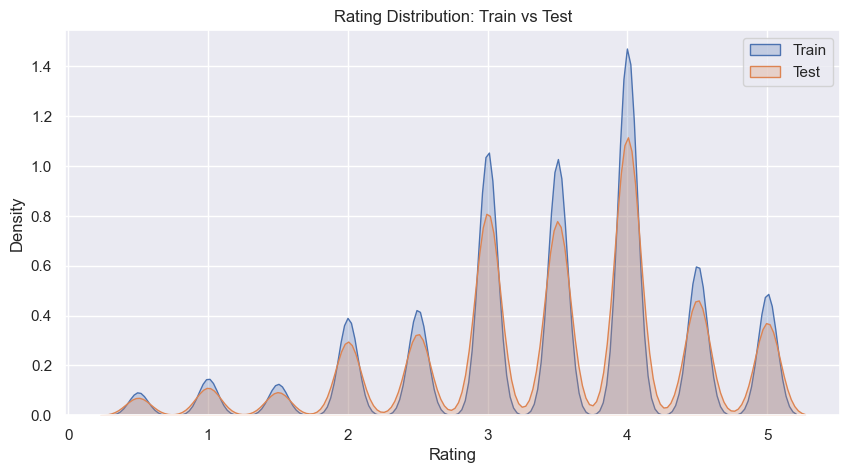

In [7]:
# Quick rating distribution comparison

plt.figure(figsize=(10, 5))

sns.kdeplot(train_df[TARGET_COL], label="Train", fill=True)

sns.kdeplot(test_df[TARGET_COL], label="Test", fill=True)

plt.title("Rating Distribution: Train vs Test")
plt.xlabel("Rating")
plt.ylabel("Density")
plt.legend()
plt.show()

## 4. Baseline Model Definition

This section builds a simple non-personalized recommender that ranks movies globally using weighted rating and popularity.

The recommender:

* does not use individual user preferences,
* recommends the same top-ranked movies to every user,
* serves as a strong benchmark before collaborative filtering models.

To improve interpretability, movie titles are loaded from the original `movies.dat` file and merged with the popularity ranking.

The baseline will later be evaluated against the test set to compare how much improvement collaborative filtering provides.

In [8]:
# Load original movie titles from raw data

movies_raw_path = PROJECT_ROOT / "data" / "raw" / "movies.dat"

movies_raw = pd.read_csv(movies_raw_path, sep="\t", encoding="latin-1", usecols=["id", "title"], low_memory=False)

movies_raw = movies_raw.rename(columns={"id": "movieID"})

print("Movies metadata loaded successfully:")
print(movies_raw.shape)

display(movies_raw.head())

Movies metadata loaded successfully:
(10197, 2)


,movieID,title
0,1,Toy story
1,2,Jumanji
2,3,Grumpy Old Men
3,4,Waiting to Exhale
4,5,Father of the Bride Part II


In [9]:
# Generate top 10 global recommendations using the popularity-based model

from src.models.popularity_recommender import PopularityRecommender

global_recommender = PopularityRecommender()
global_recommender.fit(movie_features_df=movie_features, movies_metadata_df=movies_raw)

top_recommendations = global_recommender.recommend()

print("Top 10 Global Recommendations")
print("-" * 60)

display(top_recommendations.round({"movie_avg_rating": 3, "movie_rating_count": 0, "weighted_rating": 3}))

Top 10 Global Recommendations
------------------------------------------------------------


,movieID,title,movie_avg_rating,movie_rating_count,weighted_rating
0,318,The Shawshank Redemption,4.365,1441.0,4.326
1,858,The Godfather,4.335,1134.0,4.287
2,50,The Usual Suspects,4.291,1218.0,4.247
3,2959,Fight Club,4.253,1434.0,4.217
4,296,Pulp Fiction,4.238,1537.0,4.205
5,1221,The Godfather: Part II,4.228,872.0,4.172
6,750,Dr. Strangelove or: How I Learned to Stop Worr...,4.225,842.0,4.167
7,912,Casablanca,4.228,756.0,4.164
8,4973,Le fabuleux destin d'Amélie Poulain,4.190,1137.0,4.148
9,4226,Memento,4.184,1320.0,4.148


In [10]:
# Generate recommendations using the popularity-based model

recommender = PopularityRecommender(pool_size=100)  # Sample from top 100 for some diversity
recommender.fit(movie_features_df=movie_features, movies_metadata_df=movies_raw)

# Test baseline recommender on test users

sample_test_users = test_df["userID"].drop_duplicates().sample(5, random_state=RANDOM_SEED).tolist()

print("Testing baseline recommender on sample users")
print("-" * 60)

for user_id in sample_test_users:
    print(f"\nUser {user_id}")
    top_recommendations = recommender.recommend(random_state=int(user_id / 5))
    print("Recommended movies :")

    display(top_recommendations[["title", "weighted_rating"]].head(5))

Testing baseline recommender on sample users
------------------------------------------------------------

User 64363
Recommended movies :


,title,weighted_rating
0,It's a Wonderful Life,3.946042
1,The Bridge on the River Kwai,3.954473
2,Star Wars,4.044017
3,Sen to Chihiro no kamikakushi,4.075539
4,Twelve Monkeys,3.974987



User 3710
Recommended movies :


,title,weighted_rating
0,Modern Times,3.948886
1,The Bridge on the River Kwai,3.954473
2,Schindler's List,4.134249
3,Fight Club,4.216835
4,Ran,3.965090



User 56354
Recommended movies :


,title,weighted_rating
0,The Lord of the Rings: The Fellowship of the Ring,4.054910
1,The Shawshank Redemption,4.325811
2,Le fabuleux destin d'Amélie Poulain,4.148091
3,Reservoir Dogs,3.985285
4,Gandhi,3.925576



User 7354
Recommended movies :


,title,weighted_rating
0,Goodfellas,4.097864
1,Schindler's List,4.134249
2,North by Northwest,4.059794
3,Amores perros,3.930536
4,Paths of Glory,3.926215



User 4078
Recommended movies :


,title,weighted_rating
0,The Shawshank Redemption,4.325811
1,The Lord of the Rings: The Fellowship of the Ring,4.054910
2,Some Like It Hot,3.957718
3,Double Indemnity,4.077247
4,Shichinin no samurai,4.029684


## 5. Collaborative Filtering with Matrix Factorization

### Theory

Collaborative Filtering (CF) is one of the most widely used approaches in recommendation systems. Unlike content-based methods, CF does not rely on movie metadata such as genres, actors, or tags. Instead, it learns directly from historical user-item interactions and identifies hidden preference patterns from rating behavior.

A simple user-item matrix typically contains:

* users in rows
* movies in columns
* ratings as values

However, such matrices are usually extremely sparse because each user rates only a very small subset of all available movies.

For this project:

```text
2113 users × 10197 movies ≈ 21.5 million possible interactions
```

while only:

```text
855,598 observed ratings
```

exist, resulting in approximately:

```text
~96% sparsity
```

This makes direct similarity-based methods difficult and computationally inefficient.

---

### Latent Factor Models

Latent factor models solve this problem by compressing the large sparse user-item matrix into a much smaller low-dimensional representation using hidden (latent) factors.

Instead of learning directly from:

```text
user × movie matrix
```

the model learns:

```text
user factors × latent features
movie factors × latent features
```

These latent factors capture abstract behavioral patterns such as:

* preference for action vs drama
* preference for older vs newer movies
* preference for highly rated niche films
* preference for mainstream popular content

One major advantage of this approach is that instead of working with a very high-dimensional sparse matrix containing many missing values, we work in a much smaller dense latent space.

This provides several important benefits:

* better handling of sparsity
* improved scalability
* stronger generalization
* better recommendation quality
* easier similarity computation

This is significantly more effective than purely memory-based collaborative filtering.


### Singular Value Decomposition (SVD)

In this project, collaborative filtering is first implemented using **matrix factorization with Singular Value Decomposition (SVD)**.

SVD is one of the most widely used latent factor approaches for recommendation systems because it transforms the original sparse user-item matrix into a lower-dimensional representation while preserving the most important preference patterns.

Instead of directly working with the original matrix:

```text
R = users × movies
````

the model factorizes it into three smaller matrices:

```text
R ≈ U Σ Vᵀ
```

where:

* **U** = user latent factor matrix
* **Σ** = diagonal matrix of singular values
* **Vᵀ** = movie latent factor matrix

This decomposition allows each user and each movie to be represented as a vector in a shared latent feature space.

These latent dimensions are not explicitly defined features such as genre or year, but hidden behavioral patterns automatically learned from user ratings.

---

### Mean-Centering Before Factorization

Before applying SVD, the rating matrix is mean-centered at the user level.

This means that for each user:

```text
centered rating = actual rating − user average rating
```

This step is important because users have different personal rating scales.

For example:

* one user may rate almost everything between 4 and 5
* another user may rarely give ratings above 3

Without correction, the model would learn personal scoring habits instead of actual preference patterns.

Mean-centering removes this bias and allows SVD to focus on relative preferences rather than absolute rating behavior.

After factorization, user means are added back to reconstruct final predicted ratings.

---

### Truncated SVD for Recommendation Systems

Because the full matrix contains thousands of users and movies, full decomposition would be computationally expensive and unnecessary.

Instead, we use **truncated SVD**, where only the top **k latent factors** are retained.

This means the model keeps only the strongest preference signals while discarding noise.

The reconstructed prediction matrix becomes:

```text
R̂ = U Σ Vᵀ + user mean
```

where:

* observed ratings are approximated
* missing ratings are estimated
* unseen user-movie interactions receive predicted scores

This dense reconstructed matrix is then used to generate personalized recommendations.

Movies with the highest predicted ratings among unseen items are recommended to the user.

---

### Choosing the Number of Latent Factors

One of the most important hyperparameters in matrix factorization is the number of latent factors:

```text
k
```

The higher the value of **k**, the more precisely the model can reconstruct the original matrix.

However:

* too many factors → overfitting
* too few factors → underfitting

If the model memorizes too much detail from the training data, it may perform poorly on unseen interactions.

A smaller number of factors improves generalization but may lose useful information.

Choosing the optimal value of **k** is therefore one of the key modeling decisions in collaborative filtering.

In this project, multiple values of **k** can be tested to balance recommendation quality and generalization performance.

### Testing the Model

This subsection fits the collaborative filtering model on the training set and evaluates personalized recommendations on users from the test set.

The goal is to verify that the SVD model:

* successfully learns latent user-item preference patterns,
* reconstructs the rating matrix correctly,
* generates personalized recommendations for unseen movies,
* produces different recommendations for different users.

This is the first fully personalized recommendation model in the project and serves as the main benchmark before moving to neural collaborative filtering and hybrid methods.

In [11]:
from src.models.collaborative_filtering import SVDCollaborativeFiltering

# Initialize SVD collaborative filtering model

svd_cf = SVDCollaborativeFiltering(n_factors=50, random_state=RANDOM_SEED)

print("SVD Collaborative Filtering model initialized.")

SVD Collaborative Filtering model initialized.


In [12]:
# Fit model on training interactions only

svd_cf.fit(train_df)

print("\nSVD model training completed successfully.")

Step 1: Building user-item matrix...
User-item matrix shape: (2113, 9972)
Step 2: Mean-centering user ratings...
Step 3: Converting to sparse matrix...
Step 4: Running truncated SVD with k=50...
SVD factorization completed.
Step 5: Reconstructing predictions...
Prediction matrix created successfully.

SVD model training completed successfully.


In [13]:
# Select sample users from test set

sample_test_users = test_df["userID"].drop_duplicates().sample(5, random_state=RANDOM_SEED).tolist()

print("Sample users selected from test set:")
print(sample_test_users)

Sample users selected from test set:
[64363, 3710, 56354, 7354, 4078]


In [14]:
# Generate personalized recommendations for sample users

print("Personalized Recommendations from SVD Model")
print("-" * 80)

for user_id in sample_test_users:
    print(f"\nUser {user_id}")
    print("-" * 40)

    user_recommendations = svd_cf.recommend(user_id=user_id, movies_metadata_df=movies_raw, top_n=10)

    display(user_recommendations.round({"predicted_rating": 3}))

Personalized Recommendations from SVD Model
--------------------------------------------------------------------------------

User 64363
----------------------------------------


,movieID,title,predicted_rating
0,1704,Good Will Hunting,4.163
1,4011,Snatch.,4.005
2,7153,The Lord of the Rings: The Return of the King,3.973
3,4878,Donnie Darko,3.956
4,44191,V for Vendetta,3.933
5,527,Schindler's List,3.923
6,104,Happy Gilmore,3.918
7,593,The Silence of the Lambs,3.908
8,2762,The Sixth Sense,3.906
9,4995,A Beautiful Mind,3.896



User 3710
----------------------------------------


,movieID,title,predicted_rating
0,5952,The Lord of the Rings: The Two Towers,3.308
1,7153,The Lord of the Rings: The Return of the King,3.280
2,780,Independence Day,3.128
3,3996,Wo hu cang long,3.076
4,1391,Mars Attacks!,3.040
5,1917,Armageddon,2.987
6,380,True Lies,2.974
7,231,Dumb & Dumber,2.972
8,34405,Serenity,2.959
9,2628,Star Wars: Episode I - The Phantom Menace,2.958



User 56354
----------------------------------------


,movieID,title,predicted_rating
0,1517,Austin Powers: International Man of Mystery,4.121
1,2329,American History X,4.073
2,527,Schindler's List,4.031
3,1704,Good Will Hunting,4.023
4,47,Shichinin no samurai,4.016
5,858,The Godfather,4.009
6,4226,Memento,4.003
7,58559,The Dark Knight,3.990
8,3147,The Green Mile,3.982
9,44191,V for Vendetta,3.975



User 7354
----------------------------------------


,movieID,title,predicted_rating
0,296,Pulp Fiction,4.925
1,50,The Usual Suspects,4.837
2,858,The Godfather,4.806
3,1221,The Godfather: Part II,4.552
4,1089,Reservoir Dogs,4.470
5,593,The Silence of the Lambs,4.422
6,1193,One Flew Over the Cuckoo's Nest,4.381
7,1246,Dead Poets Society,4.365
8,1136,Monty Python and the Holy Grail,4.353
9,1208,Apocalypse Now,4.314



User 4078
----------------------------------------


,movieID,title,predicted_rating
0,2028,Saving Private Ryan,4.148
1,750,Dr. Strangelove or: How I Learned to Stop Worr...,4.065
2,858,The Godfather,3.984
3,318,The Shawshank Redemption,3.958
4,904,Rear Window,3.923
5,1207,To Kill a Mockingbird,3.899
6,1262,The Great Escape,3.889
7,3996,Wo hu cang long,3.886
8,903,Vertigo,3.886
9,1278,Young Frankenstein,3.881


### Test Set Validation: Predicted vs Actual Ratings

This subsection validates the SVD recommendations using the test set by checking whether movies recommended by the model were actually rated by the user in unseen future interactions.

The goal is to compare:

* **predicted rating** generated by the SVD model
* **actual rating** from `test_df`

for movies that appear in both:

1. the recommendation list, and
2. the user’s real test interactions.

This provides a practical validation of recommendation quality and helps demonstrate whether the collaborative filtering model successfully generalizes beyond the training data.

A strong overlap between high predicted ratings and high actual ratings indicates that the latent factor model captures meaningful user preferences.

In [15]:
# Compare recommendations with real ratings from test_df

print("Predicted vs Actual Ratings on Test Set")
print("=" * 100)

for user_id in sample_test_users:
    print(f"\nUSER {user_id}")
    print("=" * 100)

    # Generate personalized recommendations

    recommendations = svd_cf.recommend(user_id=user_id, movies_metadata_df=movies_raw, top_n=50)

    # Real future ratings from test set

    user_test_ratings = test_df[test_df["userID"] == user_id][["movieID", "interaction_rating"]].merge(
        movies_raw, on="movieID", how="left"
    )

    # Find overlap between recommendations and actual future ratings

    overlap = (
        recommendations.merge(user_test_ratings, on=["movieID", "title"], how="inner")
        .rename(columns={"predicted_rating": "svd_predicted_rating", "interaction_rating": "actual_test_rating"})
        .sort_values(by="svd_predicted_rating", ascending=False)
        .reset_index(drop=True)
    )

    if overlap.empty:
        print("No overlap found between recommendations and test ratings.\n")
        continue

    # Calculate error for every prediction

    # Signed error:
    # positive -> model overpredicted
    # negative -> model underpredicted
    overlap["prediction_error"] = overlap["svd_predicted_rating"] - overlap["actual_test_rating"]

    # Absolute error:
    # easier to interpret prediction quality
    overlap["absolute_error"] = overlap["prediction_error"].abs()

    # Global validation metrics

    rmse = np.sqrt(np.mean(overlap["prediction_error"] ** 2))

    mae = np.mean(overlap["absolute_error"])

    # Display results

    print("Movies Recommended and Actually Rated Later")
    print("-" * 100)

    display(
        overlap[
            ["movieID", "title", "svd_predicted_rating", "actual_test_rating", "prediction_error", "absolute_error"]
        ].round({"svd_predicted_rating": 2, "actual_test_rating": 2, "prediction_error": 2, "absolute_error": 2})
    )

    print(f"User {user_id} Validation Metrics")
    print("-" * 50)
    print(f"RMSE: {rmse:.4f}")
    print(f"MAE:  {mae:.4f}")
    print("\n")

Predicted vs Actual Ratings on Test Set

USER 64363
Movies Recommended and Actually Rated Later
----------------------------------------------------------------------------------------------------


,movieID,title,svd_predicted_rating,actual_test_rating,prediction_error,absolute_error
0,4011,Snatch.,4.00,4.0,0.00,0.00
1,7153,The Lord of the Rings: The Return of the King,3.97,4.0,-0.03,0.03
2,44191,V for Vendetta,3.93,4.5,-0.57,0.57
3,527,Schindler's List,3.92,4.0,-0.08,0.08
4,2762,The Sixth Sense,3.91,4.0,-0.09,0.09
5,5989,Catch Me If You Can,3.87,4.0,-0.13,0.13
6,34162,Wedding Crashers,3.84,3.5,0.34,0.34
7,2353,Enemy of the State,3.78,4.0,-0.22,0.22
8,2000,Lethal Weapon,3.77,4.0,-0.23,0.23
9,858,The Godfather,3.75,2.5,1.25,1.25


User 64363 Validation Metrics
--------------------------------------------------
RMSE: 0.5232
MAE:  0.3683



USER 3710
Movies Recommended and Actually Rated Later
----------------------------------------------------------------------------------------------------


,movieID,title,svd_predicted_rating,actual_test_rating,prediction_error,absolute_error
0,5952,The Lord of the Rings: The Two Towers,3.31,5.0,-1.69,1.69


User 3710 Validation Metrics
--------------------------------------------------
RMSE: 1.6919
MAE:  1.6919



USER 56354
Movies Recommended and Actually Rated Later
----------------------------------------------------------------------------------------------------


...

User 56354 Validation Metrics
--------------------------------------------------
RMSE: 0.6101
MAE:  0.4526



USER 7354
Movies Recommended and Actually Rated Later
----------------------------------------------------------------------------------------------------


,movieID,title,svd_predicted_rating,actual_test_rating,prediction_error,absolute_error
0,296,Pulp Fiction,4.92,5.0,-0.08,0.08
1,50,The Usual Suspects,4.84,4.5,0.34,0.34
2,1089,Reservoir Dogs,4.47,4.0,0.47,0.47
3,593,The Silence of the Lambs,4.42,5.0,-0.58,0.58
4,1193,One Flew Over the Cuckoo's Nest,4.38,4.5,-0.12,0.12
5,1246,Dead Poets Society,4.36,4.5,-0.14,0.14
6,110,Braveheart,4.28,4.0,0.28,0.28
7,1617,L.A. Confidential,4.26,5.0,-0.74,0.74
8,778,Trainspotting,4.24,4.5,-0.26,0.26
9,912,Casablanca,4.09,4.0,0.09,0.09


User 7354 Validation Metrics
--------------------------------------------------
RMSE: 0.4281
MAE:  0.3271



USER 4078
Movies Recommended and Actually Rated Later
----------------------------------------------------------------------------------------------------


,movieID,title,svd_predicted_rating,actual_test_rating,prediction_error,absolute_error
0,2028,Saving Private Ryan,4.15,5.0,-0.85,0.85
1,750,Dr. Strangelove or: How I Learned to Stop Worr...,4.06,4.0,0.06,0.06
2,858,The Godfather,3.98,4.0,-0.02,0.02
3,318,The Shawshank Redemption,3.96,5.0,-1.04,1.04
4,1262,The Great Escape,3.89,5.0,-1.11,1.11
5,3996,Wo hu cang long,3.89,3.0,0.89,0.89
6,1278,Young Frankenstein,3.88,3.5,0.38,0.38
7,920,Gone with the Wind,3.86,3.0,0.86,0.86
8,2571,The Matrix,3.85,4.0,-0.15,0.15
9,1204,Lawrence of Arabia,3.84,4.0,-0.16,0.16


User 4078 Validation Metrics
--------------------------------------------------
RMSE: 0.5643
MAE:  0.4368




### Matrix Factorization via Stochastic Gradient Descent (SGD)

After implementing matrix factorization using Singular Value Decomposition (SVD), the next collaborative filtering approach uses **Matrix Factorization optimized with Stochastic Gradient Descent (SGD)**, often referred to as **Funk SVD**.

Although both methods rely on latent factor models, SGD-based matrix factorization is more directly designed for recommendation systems because it learns only from observed ratings rather than decomposing the full sparse matrix.

This makes it more scalable, flexible, and better suited for real-world recommendation tasks.

Instead of factorizing the full rating matrix:

```text
R = users × movies
```

the model learns two lower-dimensional latent matrices:


$\hat{R} \approx P × Q^T$


where:

* **P** = user latent factor matrix
* **Q** = movie latent factor matrix

Each user and each movie is represented by a vector of latent features.

These latent dimensions do not correspond to explicit attributes such as genre, director, or release year. Instead, they capture hidden behavioral patterns automatically learned from historical ratings.

Examples of such latent patterns include:

* preference for action vs drama
* preference for classic vs modern films
* preference for niche highly rated movies
* preference for mainstream popular content

This allows the model to learn personalized recommendation behavior directly from interaction data.

---

#### Prediction Formula with Bias Terms

Unlike basic matrix decomposition, SGD matrix factorization includes **bias correction terms**, which significantly improve prediction quality.

The predicted rating for user *$u$* and movie *$i$* is calculated as:

$\hat{r}_{ui} = \mu + b_u + b_i + (P_u \cdot Q_i)$

where:

* **$\mu$** = global mean rating
* **$b_u$** = user bias
* **$b_i$** = movie bias
* **$P_u$** = latent preference vector of user *$u$*
* **$Q_i$** = latent feature vector of movie *$i$*

The term:


$P_u \cdot Q_i$

is the dot product between user and movie latent vectors and represents how well a movie matches user preferences.

The bias terms are important because:

* some users consistently give higher ratings than others
* some users are naturally stricighter in scoring
* some movies are generally better received regardless of user taste

For example:

* one user may rate almost everything between 4 and 5
* another user may rarely give ratings above 3
* some movies are universally liked by most users

Without bias correction, the model could confuse personal scoring habits with actual preference patterns.

By separating global tendencies from individual preferences, the model produces more realistic and accurate predictions.

---

#### Training with Stochastic Gradient Descent

Instead of reconstructing the entire user-item matrix at once, the model learns parameters iteratively using **Stochastic Gradient Descent (SGD)**.

The training process follows these steps:

1. initialize user factors and movie factors with small random values
2. initialize user and movie biases to zero
3. loop through known ratings only
4. calculate prediction error:

```text
error = actual rating − predicted rating
```

5. update latent factors and biases to minimize this error

This process is repeated for multiple training epochs until the model converges.

---

#### Regularization and Generalization

A major challenge in recommendation systems is **overfitting**.

If the model learns too much detail from training data, it may memorize user behavior instead of generalizing to future unseen interactions.

To prevent this, SGD matrix factorization uses **L2 regularization**.

Regularization penalizes excessively large latent factor values and helps the model remain stable.

This improves:

* generalization to unseen data
* robustness against noise
* prediction stability
* recommendation quality on the test set

As a result, the model performs better not only on known ratings but also on future recommendations.

---

#### Why SGD Matrix Factorization

Compared to classical truncated SVD, SGD-based matrix factorization provides several important advantages:

* trains only on observed ratings
* scales better for sparse recommendation datasets
* includes user and item bias correction
* supports regularization against overfitting

In [16]:
from src.models.collaborative_filtering import SGDMatrixFactorization

# Initialize and train SGD Matrix Factorization model

sgd_cf = SGDMatrixFactorization(
    n_factors=75,
    learning_rate=0.01,
    regularization=0.01,
    epochs=25,
    rating_min=0.5,
    rating_max=5.0,
    random_state=RANDOM_SEED * 2,
)

sgd_cf.fit(train_df)

Step 1: Preparing training data...
Users: 2113
Movies: 9972
Step 2: Initializing latent factors...
Step 3: Training model for 25 epochs...
Epoch 01/25 | Training RMSE: 0.8710
Epoch 05/25 | Training RMSE: 0.7409
Epoch 10/25 | Training RMSE: 0.6209
Epoch 15/25 | Training RMSE: 0.5431
Epoch 20/25 | Training RMSE: 0.4982
Epoch 25/25 | Training RMSE: 0.4700
Training completed successfully.


In [20]:
# Select sample users from test set

sample_test_users_2 = test_df["userID"].drop_duplicates().sample(5, random_state=RANDOM_SEED * 2).tolist()

print("Sample users selected from test set:")
print(sample_test_users)

Sample users selected from test set:
[24234, 47780, 21693, 43699, 13694]


In [21]:
# Global evaluation on full test set

print("\nSGD Matrix Factorization - Full Test Set Evaluation")
print("=" * 100)

sgd_results = sgd_cf.evaluate(test_df)


# Detailed validation:
# Predicted vs Actual Ratings on Test Set

print("\nPredicted vs Actual Ratings on Test Set (SGD MF)")
print("=" * 100)

for user_id in sample_test_users_2:
    print(f"\nUSER {user_id}")
    print("=" * 100)

    # Generate personalized recommendations

    recommendations = sgd_cf.recommend(user_id=user_id, movies_metadata_df=movies_raw, top_n=50)

    # Real future ratings from test set

    user_test_ratings = test_df[test_df["userID"] == user_id][["movieID", "interaction_rating"]].merge(
        movies_raw, on="movieID", how="left"
    )

    # Find overlap between recommendations and actual future ratings

    overlap = (
        recommendations.merge(user_test_ratings, on=["movieID", "title"], how="inner")
        .rename(columns={"predicted_rating": "sgd_predicted_rating", "interaction_rating": "actual_test_rating"})
        .sort_values(by="sgd_predicted_rating", ascending=False)
        .reset_index(drop=True)
    )

    if overlap.empty:
        print("No overlap found between recommendations and test ratings.\n")
        continue

    # Calculate error for every prediction

    # Signed error:
    # positive -> model overpredicted
    # negative -> model underpredicted

    overlap["prediction_error"] = overlap["sgd_predicted_rating"] - overlap["actual_test_rating"]

    # Absolute error:
    # easier to interpret prediction quality

    overlap["absolute_error"] = overlap["prediction_error"].abs()

    # User-level validation metrics

    rmse = np.sqrt(np.mean(overlap["prediction_error"] ** 2))

    mae = np.mean(overlap["absolute_error"])

    # Display comparison table

    print("Movies Recommended and Actually Rated Later")
    print("-" * 100)

    display(
        overlap[
            ["movieID", "title", "sgd_predicted_rating", "actual_test_rating", "prediction_error", "absolute_error"]
        ].round({"sgd_predicted_rating": 2, "actual_test_rating": 2, "prediction_error": 2, "absolute_error": 2})
    )

    print(f"User {user_id} Validation Metrics")
    print("-" * 50)
    print(f"RMSE: {rmse:.4f}")
    print(f"MAE:  {mae:.4f}")
    print("\n")


SGD Matrix Factorization - Full Test Set Evaluation
Evaluating model on test set...
{'RMSE': np.float64(0.8195), 'MAE': 0.6197}

Predicted vs Actual Ratings on Test Set (SGD MF)

USER 24234
Movies Recommended and Actually Rated Later
----------------------------------------------------------------------------------------------------


,movieID,title,sgd_predicted_rating,actual_test_rating,prediction_error,absolute_error
0,527,Schindler's List,4.31,4.0,0.31,0.31


User 24234 Validation Metrics
--------------------------------------------------
RMSE: 0.3083
MAE:  0.3083



USER 47780
Movies Recommended and Actually Rated Later
----------------------------------------------------------------------------------------------------


,movieID,title,sgd_predicted_rating,actual_test_rating,prediction_error,absolute_error
0,2571,The Matrix,4.64,4.0,0.64,0.64
1,527,Schindler's List,4.43,4.0,0.43,0.43


User 47780 Validation Metrics
--------------------------------------------------
RMSE: 0.5466
MAE:  0.5363



USER 21693
Movies Recommended and Actually Rated Later
----------------------------------------------------------------------------------------------------


...

User 21693 Validation Metrics
--------------------------------------------------
RMSE: 0.9362
MAE:  0.8170



USER 43699
Movies Recommended and Actually Rated Later
----------------------------------------------------------------------------------------------------


,movieID,title,sgd_predicted_rating,actual_test_rating,prediction_error,absolute_error
0,1035,The Sound of Music,5.00,5.0,0.00,0.00
1,1148,Wallace & Gromit in The Wrong Trousers,5.00,4.5,0.50,0.50
2,232,Yin shi nan nu,4.98,5.0,-0.02,0.02
3,4873,Waking Life,4.95,4.0,0.95,0.95
4,37741,Capote,4.88,4.0,0.88,0.88
5,923,Citizen Kane,4.85,4.5,0.35,0.35
6,7361,Eternal Sunshine of the Spotless Mind,4.85,4.5,0.35,0.35
7,1,Toy story,4.83,5.0,-0.17,0.17
8,2396,Shakespeare in Love,4.82,5.0,-0.18,0.18
9,6377,Finding Nemo,4.82,4.0,0.82,0.82


User 43699 Validation Metrics
--------------------------------------------------
RMSE: 0.5372
MAE:  0.4298



USER 13694
Movies Recommended and Actually Rated Later
----------------------------------------------------------------------------------------------------


,movieID,title,sgd_predicted_rating,actual_test_rating,prediction_error,absolute_error
0,5971,Tonari no Totoro,5.00,4.5,0.50,0.50
1,5618,Sen to Chihiro no kamikakushi,4.68,5.0,-0.32,0.32
2,56782,There Will Be Blood,4.67,3.5,1.17,1.17


User 13694 Validation Metrics
--------------------------------------------------
RMSE: 0.7572
MAE:  0.6631


